# Importando as Bibliotecas

In [50]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


# Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


# 1. Pré-Processamento

## Limpando o Texto

In [3]:
df_teste = dados.copy()

In [4]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

In [5]:
def limpar_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)
    # 5. Expande contrações
    # Primeiro quebra o texto em palavras (texto.split())
    # Depois troca as contrações no dicionário (CONTRACTIONS)
    # Por fim junta tudo
    palavras = [CONTRACTIONS.get(p,p) for p in texto.split()]
    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [6]:
df_teste["texto_limpo"] = df_teste["review_comment_message"].apply(limpar_texto)

df_teste[["review_comment_message", "texto_limpo"]].head()

,review_comment_message,texto_limpo
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...","vendedor confiável, produto ok e entrega antes..."


## Tokenização - Quebrando texto em Unidades

In [7]:
def tokenizacao(texto):

    return word_tokenize(texto, language="portuguese")

In [8]:
df_teste["texto_tokenizado"] = df_teste["texto_limpo"].apply(tokenizacao)

df_teste[["texto_limpo", "texto_tokenizado"]].head()

,texto_limpo,texto_tokenizado
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, do, prazo, estipulado, .]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, ., no, site, a, marca, d..."
12,"mas um pouco ,travando...pelo valor ta boa.","[mas, um, pouco, ,, travando, ..., pelo, valor..."
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, ,, produto, ok, e, entre..."


## Stop Words - removendo as palavras frequentes

In [9]:
STOP_WORDS = set(stopwords.words("portuguese"))

NEGACOES = {"não", "nao", "nunca", "nem", "sem"}

STOP_WORDS_PT = STOP_WORDS - NEGACOES

In [10]:
def remove_stop_words(tokens):

    resultado = []
    for token in tokens:
        if (token.isalpha() and token not in STOP_WORDS_PT):
            resultado.append(token)
    
    return resultado

In [11]:
df_teste["texto_sem_stop_words"] = df_teste["texto_tokenizado"].apply(remove_stop_words)

df_teste[["texto_tokenizado", "texto_sem_stop_words"]].head()

,texto_tokenizado,texto_sem_stop_words
3,"[recebi, bem, antes, do, prazo, estipulado, .]","[recebi, bem, antes, prazo, estipulado]"
4,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabéns, lojas, lannister, adorei, comprar, ..."
9,"[aparelho, eficiente, ., no, site, a, marca, d...","[aparelho, eficiente, site, marca, aparelho, i..."
12,"[mas, um, pouco, ,, travando, ..., pelo, valor...","[pouco, travando, valor, ta, boa]"
15,"[vendedor, confiável, ,, produto, ok, e, entre...","[vendedor, confiável, produto, ok, entrega, an..."


## Stemming - Reduzindo palavras ao seu radical

In [12]:
from nltk.stem import RSLPStemmer
nltk.download("rslp", quiet=True)

True

In [13]:
stemmer = RSLPStemmer()

def stemmerizacao(tokens):
    resultado = []

    for token in tokens:
        resultado.append(stemmer.stem(token))
    return resultado

In [14]:
df_teste["texto_stemming"] = df_teste["texto_sem_stop_words"].apply(stemmerizacao)

df_teste[["texto_sem_stop_words", "texto_stemming"]].head()

,texto_sem_stop_words,texto_stemming
3,"[recebi, bem, antes, prazo, estipulado]","[receb, bem, ant, praz, estipul]"
4,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabém, loj, lannist, ador, compr, internet,..."
9,"[aparelho, eficiente, site, marca, aparelho, i...","[aparelh, efici, sit, marc, aparelh, impress, ..."
12,"[pouco, travando, valor, ta, boa]","[pouc, trav, val, ta, boa]"
15,"[vendedor, confiável, produto, ok, entrega, an...","[vend, confi, produt, ok, entreg, ant, praz]"


## 2. Pipeline Completo

In [15]:
def pipeline_tratamento(texto):

    texto_limpo = limpar_texto(texto)
    texto_tokenizado = tokenizacao(texto_limpo)
    texto_sem_stop_words = remove_stop_words(texto_tokenizado)
    texto_stemmer = stemmerizacao(texto_sem_stop_words)

    return " ".join(texto_stemmer)

In [16]:
dados["review"] = dados["review_comment_message"].apply(pipeline_tratamento)

dados[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


# 3. Preparando Dados Treinamento

In [18]:
sentimento = {
    "positivo": 1,
    "negativo": 0
}

dados["sentimento"] = dados["sentimento"].map(sentimento)
print("Visualizando a Variável Alvo (dados únicos)\n")
print(dados["sentimento"].unique())

Visualizando a Variável Alvo (dados únicos)

[1 0]


In [20]:
X = dados["review"]
y = dados["sentimento"]

In [22]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

print(f"Dados Treino -> {len(X_treino)}")
print(f"Dados Teste -> {len(X_teste)}")

Dados Treino -> 26194
Dados Teste -> 11226


# 4. Vetorizando Texto

* Montando um Pequeno exemplo de como irá ficar

In [29]:
corpus = [
    "Adorei o produto, chegou super rápido",
    "Produto bem embalado, mas demorou muito"
]

vec = CountVectorizer(ngram_range=(1, 2), min_df=1)

X = vec.fit_transform(corpus)

print(f"Total de Features: {len(vec.get_feature_names_out())}")

vocab = vec.get_feature_names_out()
df = pd.DataFrame(X.toarray(), columns=vocab)
print(df)

Total de Features: 19
   adorei  adorei produto  bem  bem embalado  chegou  chegou super  demorou  \
0       1               1    0             0       1             1        0   
1       0               0    1             1       0             0        1   

   demorou muito  embalado  embalado mas  mas  mas demorou  muito  produto  \
0              0         0             0    0            0      0        1   
1              1         1             1    1            1      1        1   

   produto bem  produto chegou  rápido  super  super rápido  
0            0               1       1      1             1  
1            1               0       0      0             0  


* Vectorizer vai ser salvo dentro do Pipeline

In [30]:
vectorizer = CountVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    max_features=10000
)

# 5. Modelos de NLP

In [49]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    learning_curve
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

## Modelo Naive Bayes

In [32]:
pipeline_nb = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_nb", MultinomialNB(alpha=1.0))
])

pipeline_nb.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [33]:
previsao_nb = pipeline_nb.predict(X_teste)

print("=== Resultados Modelo Naive Bayes ===")
print(classification_report(y_teste, previsao_nb))

=== Resultados Modelo Naive Bayes ===
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.92     11226
   macro avg       0.90      0.92      0.91     11226
weighted avg       0.93      0.92      0.93     11226



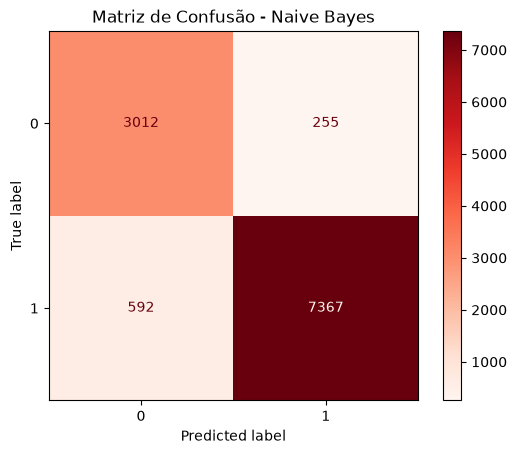

In [35]:
ConfusionMatrixDisplay.from_estimator(pipeline_nb, X_teste, y_teste, cmap="Reds")
plt.title("Matriz de Confusão - Naive Bayes")
plt.show()

## Modelo Regressão Logística

In [37]:
pipeline_rl = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_rl", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

pipeline_rl.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_rl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [38]:
previsao_rl = pipeline_rl.predict(X_teste)

print("=== Resultados Modelo Regressão Logística ===")
print(classification_report(y_teste, previsao_rl))

=== Resultados Modelo Regressão Logística ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      3267
           1       0.96      0.94      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226



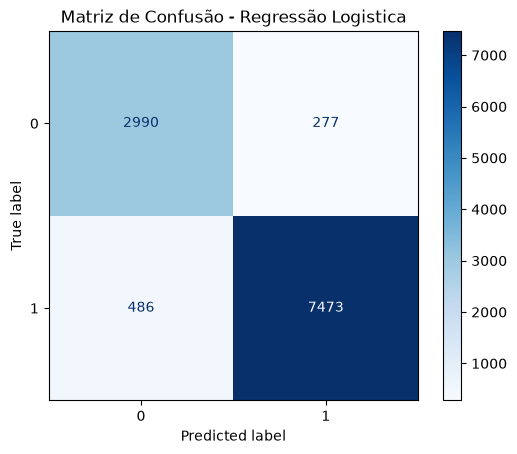

In [39]:
ConfusionMatrixDisplay.from_estimator(pipeline_rl, X_teste, y_teste, cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logistica")
plt.show()

## Modelo SVM - Support Vector Machine

In [40]:
pipeline_svm = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_svm", LinearSVC(class_weight="balanced", random_state=42))
])

pipeline_svm.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('modelo_svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float in range [0.0, 1.0] or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",0.85
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",5
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [41]:
previsao_svm = pipeline_svm.predict(X_teste)

print("=== Resultados Modelo SVM ===")
print(classification_report(y_teste, previsao_svm))

=== Resultados Modelo SVM ===
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      3267
           1       0.95      0.94      0.94      7959

    accuracy                           0.92     11226
   macro avg       0.90      0.91      0.91     11226
weighted avg       0.92      0.92      0.92     11226



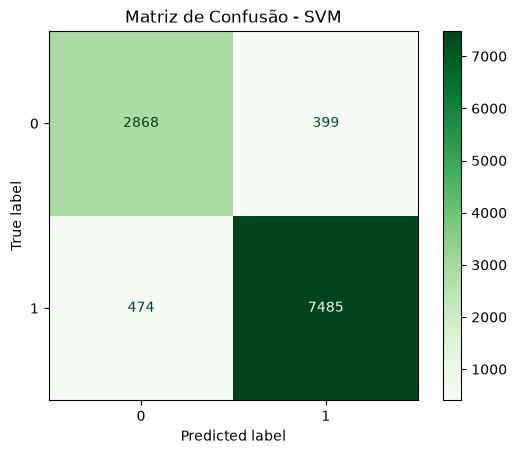

In [42]:
ConfusionMatrixDisplay.from_estimator(pipeline_svm, X_teste, y_teste, cmap="Greens")
plt.title("Matriz de Confusão - SVM")
plt.show()

# 6. Otimização Modelos - GridSearchCV

## Otimização Modelo Naive Bayes

In [43]:
pipeline_nb = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_nb", MultinomialNB())
])

param_grid_nb = {
    "modelo_nb__alpha": [0.1, 0.5, 1.0, 2.0],
    "modelo_nb__fit_prior": [True, False]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb,
    scoring="f1_macro",
    cv=cv
)

grid_nb.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_nb.best_score_}")
print(f"Melhores Hiperparâmetros -> {grid_nb.best_params_}")

Melhor Score -> 0.9090440167124898
Melhores Hiperparâmetros -> {'modelo_nb__alpha': 0.1, 'modelo_nb__fit_prior': True}


## Otimização Modelo Regressão Logística

In [44]:
pipeline_rl = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_rl", LogisticRegression(random_state=42, class_weight="balanced"))
])

param_grid_rl = {
    "modelo_rl__C": [0.1, 0.5, 1.0],
    "modelo_rl__max_iter": [1000, 2000, 3000]
}

grid_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    scoring="f1_macro",
    cv=cv
)

grid_rl.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_rl.best_score_}")
print(f"Melhores Hiperparâmetros -> {grid_rl.best_params_}")

Melhor Score -> 0.915152396494908
Melhores Hiperparâmetros -> {'modelo_rl__C': 0.5, 'modelo_rl__max_iter': 1000}


## Otimização Modelo SVM

In [45]:
pipeline_svm = Pipeline([
    ("vectorizer", vectorizer),
    ("modelo_svm", LinearSVC(class_weight="balanced", random_state=42))
])

param_grid_svm = {
    "modelo_svm__C": [0.01, 0.1, 0.5, 1.0]
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv
)

grid_svm.fit(X_treino, y_treino)

print(f"Melhor Score -> {grid_svm.best_score_}")
print(f"Melhores Hiperparâmetros -> {grid_svm.best_params_}")

Melhor Score -> 0.9145653280235526
Melhores Hiperparâmetros -> {'modelo_svm__C': 0.01}


## Analisando os Resultados

In [46]:
modelos_otimizados = {
    "Naive Bayes Otimizado": grid_nb.best_estimator_,
    "Regressão Logística": grid_rl.best_estimator_,
    "SVM Otimizado": grid_svm.best_estimator_
}

for nome, modelo in modelos_otimizados.items():
    previsao = modelo.predict(X_teste)

    print(f"Modelo -> {nome}\n")
    print(classification_report(y_teste, previsao))
    print('-'*60)

Modelo -> Naive Bayes Otimizado

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.90      0.92      0.91     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------
Modelo -> Regressão Logística

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      3267
           1       0.97      0.94      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------
Modelo -> SVM Otimizado

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      3267
           1       0.97   

In [47]:
modelo_nb_otimizado = grid_nb.best_estimator_
modelo_rl_otimizado = grid_rl.best_estimator_
modelo_svm_otimizado = grid_svm.best_estimator_

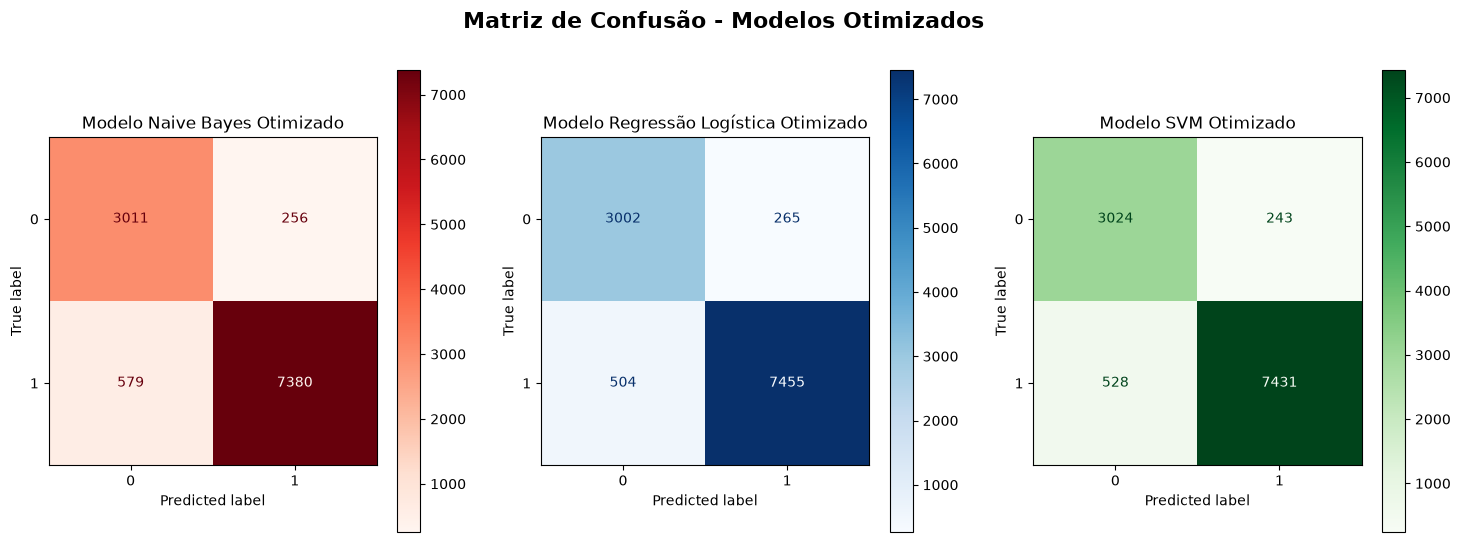

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))

ConfusionMatrixDisplay.from_estimator(modelo_nb_otimizado, X_teste, y_teste, cmap="Reds", ax=ax[0])
ax[0].set_title("Modelo Naive Bayes Otimizado")

ConfusionMatrixDisplay.from_estimator(modelo_rl_otimizado, X_teste, y_teste, cmap="Blues", ax=ax[1])
ax[1].set_title("Modelo Regressão Logística Otimizado")

ConfusionMatrixDisplay.from_estimator(modelo_svm_otimizado, X_teste, y_teste, cmap="Greens", ax=ax[2])
ax[2].set_title("Modelo SVM Otimizado")

plt.suptitle("Matriz de Confusão - Modelos Otimizados",fontsize=16, fontweight="bold")
plt.show()

# 7. Verificando Learning Curve

In [51]:
train_sizes, train_score, val_score = learning_curve(
    estimator=modelo_svm_otimizado,
    X=X_treino,
    y=y_treino,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)

val_mean = val_score.mean(axis=1)
val_std = val_score.std(axis=1)

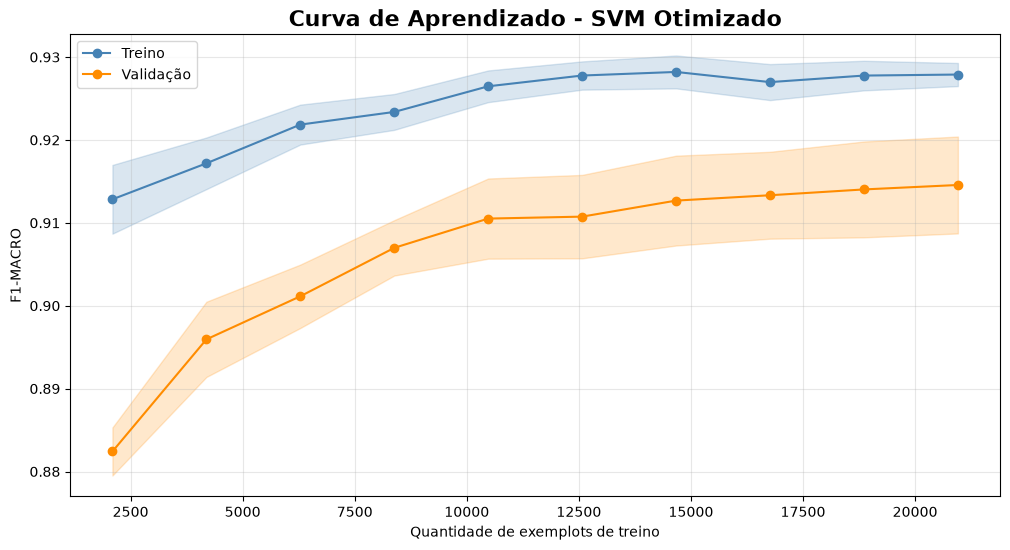

In [53]:
plt.figure(figsize=(12,6))

# Curva do Treino
plt.plot(train_sizes, train_mean, marker='o', color="steelblue", label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="steelblue", alpha=0.2)

# Curva da Validação
plt.plot(train_sizes, val_mean, marker='o', color="darkorange", label="Validação")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="darkorange", alpha=0.2)

plt.title("Curva de Aprendizado - SVM Otimizado", fontsize=16, fontweight="bold")
plt.xlabel("Quantidade de exemplots de treino")
plt.ylabel("F1-MACRO")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
gap_final = train_mean[-1] - val_mean[-1]

print(f"Último f1-macro Treino -> {train_mean[-1]:.3f}")
print(f"Último f1-macro Validação -> {val_mean[-1]:.3f}")
print(f"Gap final -> {gap_final:.3f}")

Último f1-macro Treino -> 0.928
Último f1-macro Validação -> 0.915
Gap final -> 0.013


# 8. Avaliação Final do Conjunto de Teste

In [56]:
modelo_final = grid_svm.best_estimator_

previsao_final = modelo_final.predict(X_teste)

In [57]:
print("=== Avaliação Final do Modelo SVM Otimizado ===")
print(classification_report(y_teste, previsao_final))

=== Avaliação Final do Modelo SVM Otimizado ===
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226



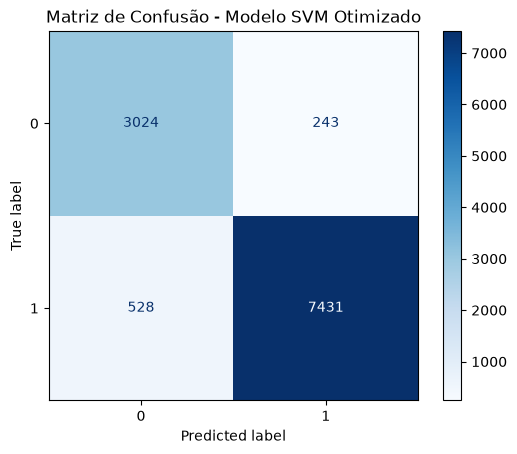

In [58]:
ConfusionMatrixDisplay.from_predictions(y_teste, previsao_final, cmap="Blues")
plt.title("Matriz de Confusão - Modelo SVM Otimizado")
plt.show()